# Experiment 1 - BaseLine Model

```
Image
  ↓
32 × 32
  ↓
3 channels
  ↓
RGB
  ↓
Natural images
  ↓
10 classes

0 → airplane
1 → automobile
2 → bird
3 → cat
4 → deer
5 → dog
6 → frog
7 → horse
8 → ship
9 → truck

so 10 logits

```

```
Input
[3 × 32 × 32]
       ↓
Conv2D
3 → 32
3×3
padding=1
       ↓
ReLU
       ↓
MaxPool
2×2
       ↓
[32 × 16 × 16]
       ↓
Conv2D
32 → 64
3×3
padding=1
       ↓
ReLU
       ↓
MaxPool
2×2
       ↓
[64 × 8 × 8]
       ↓
Flatten
       ↓
4096
       ↓
Linear
4096 → 10
       ↓
10 logits

```

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader
from torchvision import datasets, transforms

In [2]:
transform = transforms.ToTensor()

train_dataset = datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

In [3]:
train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False
)

In [4]:
images,labels = next(iter(train_loader))
print(images.shape)
print(labels.shape)
print(labels[:10])

torch.Size([64, 3, 32, 32])
torch.Size([64])
tensor([5, 6, 8, 4, 5, 1, 0, 0, 1, 6])


In [5]:
class SimpleCIFAR10CNN(nn.Module):

    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(

            nn.Conv2d(
                in_channels=3,
                out_channels=32,
                kernel_size=3,
                padding=1
            ),

            nn.ReLU(),

            nn.MaxPool2d(2),

            nn.Conv2d(
                in_channels=32,
                out_channels=64,
                kernel_size=3,
                padding=1
            ),

            nn.ReLU(),

            nn.MaxPool2d(2)
        )

        self.classifier = nn.Linear(
            64 * 8 * 8,
            10
        )

    def forward(self, x):

        x = self.features(x)

        x = torch.flatten(x, 1)

        x = self.classifier(x)

        return x

In [6]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

model = SimpleCIFAR10CNN().to(device)

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

In [7]:
epochs = 10

for epoch in range(epochs):

    model.train()

    running_loss = 0.0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader)

    print(
        f"Epoch: {epoch+1} | Loss: {avg_loss:.4f}"
    )

Epoch: 1 | Loss: 1.4943
Epoch: 2 | Loss: 1.1623
Epoch: 3 | Loss: 1.0259
Epoch: 4 | Loss: 0.9406
Epoch: 5 | Loss: 0.8832
Epoch: 6 | Loss: 0.8359
Epoch: 7 | Loss: 0.7882
Epoch: 8 | Loss: 0.7519
Epoch: 9 | Loss: 0.7194
Epoch: 10 | Loss: 0.6886


In [8]:
model.eval()

correct = 0
total = 0

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        predictions = outputs.argmax(dim=1)

        total += labels.size(0)

        correct += (
            predictions == labels
        ).sum().item()

accuracy = 100 * correct / total

print(f"Test Accuracy: {accuracy:.2f}%")

Test Accuracy: 70.03%


In [9]:
total_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print("Total parameters:", total_params)

Total parameters: 60362


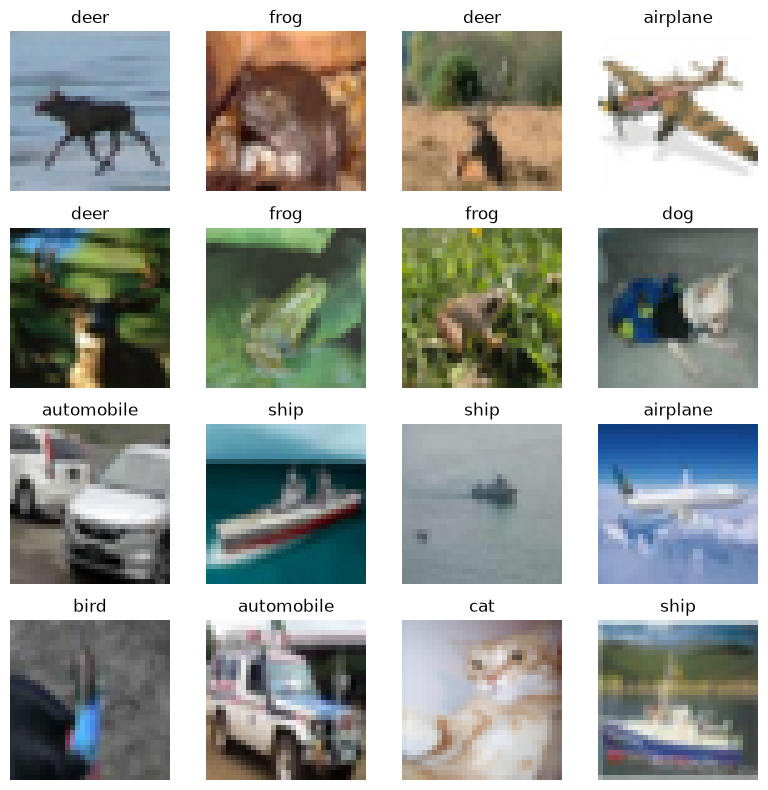

In [10]:
import matplotlib.pyplot as plt

images, labels = next(iter(train_loader))

plt.figure(figsize=(8, 8))

for i in range(16):

    plt.subplot(4, 4, i + 1)

    plt.imshow(
        images[i].permute(1, 2, 0)
    )

    plt.title(
        train_dataset.classes[labels[i]]
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

# Experiment 2(Different Kernel Sizes)

In [ ]:
# we already done on 3*3 now lets test on 5*5 kernel size later we can compare with that

In [11]:
class CIFAR10CNN_5x5(nn.Module):

    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(

            nn.Conv2d(
                in_channels=3,
                out_channels=32,
                kernel_size=5,
                padding=2
            ),

            nn.ReLU(),

            nn.MaxPool2d(2),

            nn.Conv2d(
                in_channels=32,
                out_channels=64,
                kernel_size=5,
                padding=2
            ),

            nn.ReLU(),

            nn.MaxPool2d(2)
        )

        self.classifier = nn.Linear(
            64 * 8 * 8,
            10
        )

    def forward(self, x):

        x = self.features(x)

        x = torch.flatten(x, 1)

        x = self.classifier(x)

        return x

In [12]:
model = CIFAR10CNN_5x5().to(device)

total_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print("Total parameters:", total_params)

Total parameters: 94666


In [13]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

epochs = 10

for epoch in range(epochs):

    model.train()

    running_loss = 0.0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader)

    print(
        f"Epoch: {epoch+1} | Loss: {avg_loss:.4f}"
    )

Epoch: 1 | Loss: 1.5045
Epoch: 2 | Loss: 1.1664
Epoch: 3 | Loss: 1.0176
Epoch: 4 | Loss: 0.9400
Epoch: 5 | Loss: 0.8836
Epoch: 6 | Loss: 0.8364
Epoch: 7 | Loss: 0.8008
Epoch: 8 | Loss: 0.7698
Epoch: 9 | Loss: 0.7394
Epoch: 10 | Loss: 0.7164


In [14]:
model.eval()

correct = 0
total = 0

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        predictions = outputs.argmax(dim=1)

        total += labels.size(0)

        correct += (
            predictions == labels
        ).sum().item()

accuracy = 100 * correct / total

print(f"Test Accuracy: {accuracy:.2f}%")

Test Accuracy: 69.83%


```
    Comparison between 3*3 vs 5*5 kernel size
```

| Metric                |        3×3 |          5×5 |
| --------------------- | ---------: | -----------: |
| Parameters            | **60,362** |   **94,666** |
| Final loss            | **0.6886** |       0.7164 |
| Test accuracy         | **70.03%** |       69.83% |
| Difference            |          — | **−0.20 pp** |
| Receptive field/layer |    Smaller |       Larger |
| Parameter cost        |      Lower |       Higher |

```
A larger kernel gives a larger local receptive field, but that extra capacity comes with significantly more parameters and computation. In our experiment, the 5×5 model did not translate that extra capacity into better test accuracy.
```


# Experiment 3 — Different Numbers of Filters

In [15]:
class CIFAR10CNN_Filters(nn.Module):

    def __init__(self, f1, f2):
        super().__init__()

        self.features = nn.Sequential(

            nn.Conv2d(
                3,
                f1,
                kernel_size=3,
                padding=1
            ),

            nn.ReLU(),

            nn.MaxPool2d(2),

            nn.Conv2d(
                f1,
                f2,
                kernel_size=3,
                padding=1
            ),

            nn.ReLU(),

            nn.MaxPool2d(2)
        )

        self.classifier = nn.Linear(
            f2 * 8 * 8,
            10
        )

    def forward(self, x):

        x = self.features(x)

        x = torch.flatten(x, 1)

        x = self.classifier(x)

        return x

In [16]:
model_small = CIFAR10CNN_Filters(
    f1=16,
    f2=32
).to(device)

In [17]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model_small.parameters(),
    lr=0.001
)

epochs = 10

for epoch in range(epochs):

    model_small.train()

    running_loss = 0.0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model_small(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader)

    print(
        f"Epoch: {epoch+1} | Loss: {avg_loss:.4f}"
    )

Epoch: 1 | Loss: 1.5698
Epoch: 2 | Loss: 1.2680
Epoch: 3 | Loss: 1.1550
Epoch: 4 | Loss: 1.0763
Epoch: 5 | Loss: 1.0239
Epoch: 6 | Loss: 0.9776
Epoch: 7 | Loss: 0.9455
Epoch: 8 | Loss: 0.9200
Epoch: 9 | Loss: 0.8982
Epoch: 10 | Loss: 0.8772


In [19]:
model_small.eval()

correct = 0
total = 0

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model_small(images)

        predictions = outputs.argmax(dim=1)

        total += labels.size(0)

        correct += (
            predictions == labels
        ).sum().item()

accuracy = 100 * correct / total

print(f"Test Accuracy: {accuracy:.2f}%")

Test Accuracy: 66.45%


In [20]:
model_large = CIFAR10CNN_Filters(64, 128).to(device)

In [21]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model_large.parameters(),
    lr=0.001
)

epochs = 10

for epoch in range(epochs):

    model_large.train()

    running_loss = 0.0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model_large(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader)

    print(
        f"Epoch: {epoch+1} | Loss: {avg_loss:.4f}"
    )

Epoch: 1 | Loss: 1.4362
Epoch: 2 | Loss: 1.0874
Epoch: 3 | Loss: 0.9611
Epoch: 4 | Loss: 0.8858
Epoch: 5 | Loss: 0.8246
Epoch: 6 | Loss: 0.7775
Epoch: 7 | Loss: 0.7372
Epoch: 8 | Loss: 0.7019
Epoch: 9 | Loss: 0.6702
Epoch: 10 | Loss: 0.6402


In [22]:
model_large.eval()

correct = 0
total = 0

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model_large(images)

        predictions = outputs.argmax(dim=1)

        total += labels.size(0)

        correct += (
            predictions == labels
        ).sum().item()

accuracy = 100 * correct / total

print(f"Test Accuracy: {accuracy:.2f}%")

Test Accuracy: 71.06%


```
Our experiment demonstrated three things:

① Too few filters can limit capacity
16 → 32
25,578 params
66.45%
② Increasing filters can improve representation
32 → 64
60,362 params
70.03%
③ More capacity eventually gives smaller gains
64 → 128
157,578 params
71.06%

```
So the key concept is:

$$ \boxed{\text{More filters} \rightarrow \text{more representational capacity}} $$

but:

$$ \boxed{\text{More capacity} \not\rightarrow \text{proportionally more accuracy}} $$

That's diminishing returns. 

```
    We get only smaller gains even though params get doubled which is computationally expenseive
    for smaller gain so are continuing with baseline model
```

# Experiment 4 - Pooling

In [23]:
# our Baseline Model is already havigg Maxpool
# so we are going to implement the average pool alone
# then we can compare both

In [24]:
class CIFAR10CNN_AvgPool(nn.Module):

    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(

            nn.Conv2d(
                3,
                32,
                kernel_size=3,
                padding=1
            ),

            nn.ReLU(),

            nn.AvgPool2d(2),

            nn.Conv2d(
                32,
                64,
                kernel_size=3,
                padding=1
            ),

            nn.ReLU(),

            nn.AvgPool2d(2)
        )

        self.classifier = nn.Linear(
            64 * 8 * 8,
            10
        )

    def forward(self, x):

        x = self.features(x)

        x = torch.flatten(x, 1)

        x = self.classifier(x)

        return x

In [25]:
model_avg = CIFAR10CNN_AvgPool().to(device)

total_params = sum(
    p.numel()
    for p in model_avg.parameters()
    if p.requires_grad
)

print("Parameters:", total_params)

Parameters: 60362


In [26]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model_avg.parameters(),
    lr=0.001
)

epochs = 10

for epoch in range(epochs):

    model_avg.train()

    running_loss = 0.0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model_avg(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader)

    print(
        f"Epoch: {epoch+1} | Loss: {avg_loss:.4f}"
    )

Epoch: 1 | Loss: 1.5815
Epoch: 2 | Loss: 1.2993
Epoch: 3 | Loss: 1.1789
Epoch: 4 | Loss: 1.0943
Epoch: 5 | Loss: 1.0182
Epoch: 6 | Loss: 0.9590
Epoch: 7 | Loss: 0.9111
Epoch: 8 | Loss: 0.8740
Epoch: 9 | Loss: 0.8450
Epoch: 10 | Loss: 0.8144


In [27]:
model_avg.eval()

correct = 0
total = 0

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model_avg(images)

        predictions = outputs.argmax(dim=1)

        total += labels.size(0)

        correct += (
            predictions == labels
        ).sum().item()

accuracy = 100 * correct / total

print(f"Test Accuracy: {accuracy:.2f}%")

Test Accuracy: 67.79%


|                     |    MaxPool |      AvgPool |
| ------------------- | ---------: | -----------: |
| Kernel              |        3×3 |          3×3 |
| Filters             |    32 → 64 |      32 → 64 |
| Pooling             |    **Max** |  **Average** |
| Parameters          |     60,362 |       60,362 |
| Final loss          | **0.6886** |       0.8144 |
| Test accuracy       | **70.03%** |       67.79% |
| Accuracy difference |          — | **−2.24 pp** |


```
In this CIFAR-10 CNN, MaxPool preserved useful strong local activations better than AvgPool, resulting in higher training    performance and test accuracy after 10 epochs.
```

# Experiment 5 - BatchNorm

In [28]:
class CIFAR10CNN_BatchNorm(nn.Module):

    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(

            nn.Conv2d(
                3,
                32,
                kernel_size=3,
                padding=1
            ),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(
                32,
                64,
                kernel_size=3,
                padding=1
            ),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Linear(
            64 * 8 * 8,
            10
        )

    def forward(self, x):

        x = self.features(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)

        return x

In [29]:
model_bn = CIFAR10CNN_BatchNorm().to(device)

total_params = sum(
    p.numel()
    for p in model_bn.parameters()
    if p.requires_grad
)

print("Parameters:", total_params)

Parameters: 60554


In [30]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model_bn.parameters(),
    lr=0.001
)

epochs = 10

for epoch in range(epochs):

    model_bn.train()

    running_loss = 0.0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model_bn(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader)

    print(
        f"Epoch: {epoch+1} | Loss: {avg_loss:.4f}"
    )

Epoch: 1 | Loss: 1.3055
Epoch: 2 | Loss: 0.9709
Epoch: 3 | Loss: 0.8467
Epoch: 4 | Loss: 0.7740
Epoch: 5 | Loss: 0.7169
Epoch: 6 | Loss: 0.6623
Epoch: 7 | Loss: 0.6192
Epoch: 8 | Loss: 0.5859
Epoch: 9 | Loss: 0.5492
Epoch: 10 | Loss: 0.5151


In [31]:
model_bn.eval()

correct = 0
total = 0

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model_bn(images)

        predictions = outputs.argmax(dim=1)

        total += labels.size(0)

        correct += (
            predictions == labels
        ).sum().item()

accuracy = 100 * correct / total

print(f"Test Accuracy: {accuracy:.2f}%")

Test Accuracy: 60.26%


| Metric              | Baseline CNN | CNN + BatchNorm |
| ------------------- | -----------: | --------------: |
| Parameters          |       60,362 |          60,554 |
| Final training loss |   **0.6886** |      **0.5151** |
| Test accuracy       |   **70.03%** |      **60.26%** |
| Epoch 1 loss        |       1.4943 |      **1.3055** |
| Epoch 10 loss       |       0.6886 |      **0.5151** |

```
   Here Model performed well on trainn dataset by reducing the loss but it did not generalized well
   that's why test accuracy is reduced
```

# Experiment 6 — CNN with Dropout

In [32]:
class CIFAR10CNN_Dropout(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.Dropout(p=0.5),
            nn.Linear(64 * 8 * 8, 10)
        )

    def forward(self, x):
        x = self.features(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x

In [33]:
model = CIFAR10CNN_Dropout().to(device)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

for epoch in range(10):

    model.train()

    running_loss = 0.0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    epoch_loss = running_loss / len(train_loader)

    print(
        f"Epoch: {epoch+1} | "
        f"Loss: {epoch_loss:.4f}"
    )

Epoch: 1 | Loss: 1.5334
Epoch: 2 | Loss: 1.2340
Epoch: 3 | Loss: 1.1099
Epoch: 4 | Loss: 1.0398
Epoch: 5 | Loss: 0.9949
Epoch: 6 | Loss: 0.9472
Epoch: 7 | Loss: 0.9214
Epoch: 8 | Loss: 0.8950
Epoch: 9 | Loss: 0.8679
Epoch: 10 | Loss: 0.8509


In [34]:
model.eval()

correct = 0
total = 0

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total

print(f"Test Accuracy: {accuracy:.2f}%")

Test Accuracy: 71.53%


| Metric           | Baseline CNN | CNN + Dropout |
| ---------------- | -----------: | ------------: |
| Parameters       |       60,362 |        60,362 |
| Final train loss |   **0.6886** |        0.8509 |
| Test accuracy    |       70.03% |    **71.53%** |
| Dropout          |            ❌ |           0.5 |
| Accuracy change  |            — |  **+1.50 pp** |


| Experiment    | Architecture change        |  Params | Test Accuracy |
| ------------- | -------------------------- | ------: | ------------: |
| Baseline      | 3×3, 32→64, MaxPool        |  60,362 |    **70.03%** |
| Kernel        | 5×5                        |  94,666 |        69.83% |
| Filters-small | 16→32                      |  25,578 |        66.45% |
| Filters-large | 64→128                     | 157,578 |        71.06% |
| AvgPool       | AvgPool instead of MaxPool |  60,362 |        67.79% |
| BatchNorm     | Conv → BN → ReLU           |  60,554 |        60.26% |
| Dropout       | Dropout 0.5                |  60,362 |    **71.53%** |


# 📘 MODULE 19 — BASIC CNN IMPLEMENTATION

## Final Learning Notes — Concepts, Experiments & Valuable Insights

---

# 1. 🎯 Purpose of This Module

This module was not just about learning how to write a CNN.

The real objective was to understand:

> **How architectural choices affect learning, computational cost, training behavior, and generalization.**

We built a simple CNN and then systematically changed **one major component at a time**.

This is the mindset of practical deep learning:

```text
Build baseline
     ↓
Change ONE thing
     ↓
Train
     ↓
Measure
     ↓
Compare
     ↓
Understand WHY
```

---

# 2. 🧠 Baseline CNN

The basic CIFAR-10 architecture:

```text
Input
[3 × 32 × 32]
      ↓
Conv 3 → 32
      ↓
ReLU
      ↓
MaxPool
      ↓
[32 × 16 × 16]
      ↓
Conv 32 → 64
      ↓
ReLU
      ↓
MaxPool
      ↓
[64 × 8 × 8]
      ↓
Flatten
      ↓
4096
      ↓
Linear
      ↓
10 logits
```

### Why this architecture?

It demonstrates the fundamental CNN pipeline:

$$
\boxed{
\text{Image}
\rightarrow
\text{Features}
\rightarrow
\text{Downsampling}
\rightarrow
\text{Classification}
}
$$

---

# 3. 🔥 CNN Feature Learning

A convolution layer learns **filters**.

Early filters can learn patterns such as:

* edges
* orientations
* corners
* simple textures

Later layers can combine these into increasingly meaningful patterns.

Conceptually:

```text
Pixels
 ↓
Edges
 ↓
Textures / simple patterns
 ↓
Parts
 ↓
Higher-level visual features
 ↓
Class prediction
```

This is one of the fundamental reasons CNNs work well for images.

---

# 4. 🔥 Tensor Shape Reasoning

For CIFAR-10:

$$
[3,32,32]
$$

means:

* 3 → RGB channels
* 32 → height
* 32 → width

A batch becomes:

$$
[B,3,32,32]
$$

After the first convolution:

$$
[B,32,32,32]
$$

After pooling:

$$
[B,32,16,16]
$$

After the second convolution:

$$
[B,64,16,16]
$$

After the second pooling:

$$
[B,64,8,8]
$$

Flattening:

$$
64\times8\times8=4096
$$

Therefore:

$$
[B,64,8,8]
\rightarrow
[B,4096]
$$

### 🔥 Practical rule

When debugging CNNs, **always track tensor shapes**.

A huge number of CNN implementation errors are shape-related.

---

# 5. 🔥 Convolution Parameter Count

For a convolution:

$$
\boxed{
\text{Parameters}
=
K_HK_WC_{in}C_{out}+C_{out}
}
$$

where:

* \(K_H,K_W\) → kernel dimensions
* \(C_{in}\) → input channels
* \(C_{out}\) → output channels
* final \(C_{out}\) → bias terms

For example, first layer:

$$
3\times3\times3\times32+32
$$

$$
=896
$$

### Important insight

CNN parameter count depends heavily on:

$$
K^2 \times C_{in}\times C_{out}
$$

So increasing kernel size or channel count can dramatically increase computational cost.

---

# 6. 🧪 Experiment 2 — CIFAR-10 Baseline

Baseline result:

$$
\boxed{70.03\%}
$$

Final training loss:

$$
\boxed{0.6886}
$$

Parameters:

$$
\boxed{60,362}
$$

This becomes our **reference point**.

Every later experiment should be compared against this baseline.

---

# 7. 🔥 Experiment 3 — Kernel Size

We compared:

$$
3\times3
$$

against:

$$
5\times5
$$

### Results

| Kernel | Parameters |   Accuracy |
| ------ | ---------: | ---------: |
| 3×3    |     60,362 | **70.03%** |
| 5×5    |     94,666 |     69.83% |

The 5×5 model had:

$$
94,666-60,362=34,304
$$

additional parameters.

That's approximately:

$$
56.8\%
$$

more parameters.

Yet accuracy changed from:

$$
70.03\rightarrow69.83\%
$$

---

## 🔥 Valuable insight

> **A larger kernel does not automatically produce a better CNN.**

A 5×5 kernel sees a larger local region, but it also costs more parameters.

This introduces the idea of a **trade-off between receptive field and computational cost**.

---

# 8. 🔥 Why 3×3 Kernels Are So Important

A stack of multiple 3×3 convolutions can produce a larger effective receptive field while introducing nonlinearities between them.

For example:

```text
3×3
 ↓
3×3
```

has an effective receptive field of approximately:

$$
5\times5
$$

while providing an additional nonlinear transformation.

This idea became particularly important in architectures such as **VGG**.

### Core lesson

> Don't think only in terms of kernel size. Think about **effective receptive field + depth + nonlinearities + parameter efficiency**.

---

# 9. 🧪 Experiment 4 — Number of Filters

We compared:

```text
Small:     16 → 32
Baseline:  32 → 64
Large:     64 → 128
```

### Results

| Filters  | Parameters | Accuracy |
| -------- | ---------: | -------: |
| 16 → 32  |     25,578 |   66.45% |
| 32 → 64  |     60,362 |   70.03% |
| 64 → 128 |    157,578 |   71.06% |

---

# 10. 🔥 What Do More Filters Actually Mean?

A filter learns a feature detector.

More filters allow the network to learn **more types of features**.

Conceptually:

```text
32 filters
 ↓
32 feature maps

64 filters
 ↓
64 feature maps

128 filters
 ↓
128 feature maps
```

Therefore increasing filters increases the model's **representational capacity**.

---

# 11. 🔥 Diminishing Returns

The results are particularly valuable:

### Small → Baseline

$$
66.45\rightarrow70.03
$$

Improvement:

$$
+3.58\text{ percentage points}
$$

### Baseline → Large

$$
70.03\rightarrow71.06
$$

Improvement:

$$
+1.03\text{ percentage points}
$$

So doubling the channel widths again produced a much smaller improvement.

Meanwhile:

$$
60,362\rightarrow157,578
$$

That's an increase of:

$$
97,216
$$

parameters, or roughly **161%**.

### 🔥 Core lesson

> **Increasing model capacity can help, but returns are not necessarily proportional to the additional parameters.**

This is the beginning of understanding **capacity vs efficiency**.

---

# 12. 🧪 Experiment 5 — MaxPool vs AvgPool

We compared:

### MaxPool

Takes the strongest activation.

Example:

$$
\begin{bmatrix}
1&7\\
3&2
\end{bmatrix}
$$

MaxPool:

$$
\boxed{7}
$$

### AvgPool

Calculates the average:

$$
\frac{1+7+3+2}{4}
=
\boxed{3.25}
$$

---

# 13. 🔥 Intuition

### MaxPool asks:

> **"Is a strong feature present in this region?"**

### AvgPool asks:

> **"What is the overall activation level in this region?"**

This produces different representations.

---

# 14. Results

| Pooling | Parameters |   Accuracy |
| ------- | ---------: | ---------: |
| MaxPool |     60,362 | **70.03%** |
| AvgPool |     60,362 |     67.79% |

Difference:

$$
67.79-70.03
=
-2.24
$$

percentage points.

### Important:

Pooling itself adds **no trainable parameters**.

Therefore both models have:

$$
\boxed{60,362}
$$

parameters.

---

# 15. 🔥 Pooling Has Two Main Roles

Pooling:

### 1. Downsamples spatial dimensions

Example:

$$
32\times32
\rightarrow
16\times16
$$

### 2. Aggregates local information

MaxPool:

$$
\text{strongest response}
$$

AvgPool:

$$
\text{average response}
$$

Therefore pooling isn't merely "making the image smaller."

It also changes **what information is retained**.

---

# 16. 🧪 Experiment 6 — BatchNorm

Batch Normalization transforms activations using:

$$
\mu_B=
\frac{1}{m}
\sum_i x_i
$$

$$
\sigma_B^2=
\frac{1}{m}
\sum_i(x_i-\mu_B)^2
$$

Normalize:

$$
\hat{x}
=
\frac{x-\mu_B}
{\sqrt{\sigma_B^2+\epsilon}}
$$

Then learn:

$$
\boxed{
y=\gamma\hat{x}+\beta
}
$$

where:

* \(\gamma\) → learned scale
* \(\beta\) → learned shift

---

# 17. 🔥 BatchNorm Is More Than "Normalization"

The useful mental model:

```text
Conv
 ↓
BatchNorm
 ↓
ReLU
```

BatchNorm helps control activation distributions during training and can change optimization dynamics.

For CNNs, `BatchNorm2d(C)` operates channel-wise over the batch/spatial dimensions.

---

# 18. 🔥 Train vs Evaluation Behavior

During training:

```text
Batch statistics
      ↓
BatchNorm
      ↓
Running statistics updated
```

During evaluation:

```text
Stored running statistics
      ↓
BatchNorm
      ↓
Prediction
```

Therefore:

$$
\boxed{\texttt{model.train()} \neq \texttt{model.eval()}}
$$

This is extremely important when debugging BatchNorm models.

---

# 19. BatchNorm Experiment Result

Your result:

$$
\boxed{60.26\%}
$$

with final training loss:

$$
\boxed{0.5151}
$$

Baseline:

$$
70.03\%
$$

with loss:

$$
0.6886
$$

So:

### Training loss improved:

$$
0.6886\rightarrow0.5151
$$

### Test accuracy decreased:

$$
70.03\rightarrow60.26\%
$$

---

# 20. 🚨 Critical ML Lesson From BatchNorm

This is one of the most valuable observations in the entire module:

> **Lower training loss does not guarantee better test performance.**

Training optimization:

$$
\boxed{\text{Better}}
$$

Generalization in this particular run:

$$
\boxed{\text{Worse}}
$$

We should **not** conclude:

> "BatchNorm is bad."

The correct conclusion is:

> Under this exact architecture, optimizer, learning rate, and 10-epoch setup, BatchNorm produced lower training loss but lower test accuracy.

This distinction is extremely important in real experimentation.

---

# 21. 🧪 Experiment 7 — Dropout

Dropout randomly removes activations during training.

If:

$$
p=0.5
$$

approximately 50% of activations are dropped during each training pass.

Example:

```text
Before:
[2, 4, 6, 8]

Mask:
[1, 0, 1, 0]

After:
[2, 0, 6, 0]
```

The exact pattern changes between training passes.

---

# 22. 🔥 Why Dropout?

Without Dropout:

```text
Specific neurons
       ↓
Strong dependency
       ↓
Potential overfitting
```

With Dropout:

```text
Random activations removed
       ↓
Network cannot rely heavily
on specific activations
       ↓
More distributed representations
       ↓
Potentially better generalization
```

Therefore Dropout is primarily a **regularization technique**.

---

# 23. 🔥 Dropout Training vs Evaluation

### Training

$$
\boxed{\text{Dropout ACTIVE}}
$$

### Evaluation

$$
\boxed{\text{Dropout DISABLED}}
$$

Therefore:

```text
model.train()
→ Dropout active

model.eval()
→ Dropout inactive
```

This is why correct train/evaluation mode is essential.

---

# 24. 🔥 Inverted Dropout

For:

$$
p=0.5
$$

a surviving activation is scaled by:

$$
\frac{1}{1-p}
=
\frac{1}{0.5}
=
2
$$

If the original activation is 4:

```text
Dropped:
0

Kept:
4 × 2 = 8
```

Expected value remains approximately:

$$
0.5(0)+0.5(8)=4
$$

This keeps activation magnitude consistent.

---

# 25. Dropout Experiment Result

Your model:

$$
\boxed{71.53\%}
$$

Baseline:

$$
70.03\%
$$

Improvement:

$$
\boxed{+1.50\text{ percentage points}}
$$

But training loss became:

$$
0.8509
$$

compared with:

$$
0.6886
$$

for the baseline.

---

# 26. 🔥 Another Extremely Important Lesson

Your Dropout experiment demonstrated:

```text
Training performance
        ↓
     WORSE

Test performance
        ↓
     BETTER
```

This is not contradictory.

Dropout deliberately makes training more difficult.

The goal is not simply:

$$
\min L_{train}
$$

The practical goal is better:

$$
\boxed{\text{Generalization to unseen data}}
$$

---

# 27. 🏆 Complete Experimental Results

| Experiment    | Main Change      | Parameters | Test Accuracy |
| ------------- | ---------------- | ---------: | ------------: |
| Baseline      | 3×3 + MaxPool    |     60,362 |    **70.03%** |
| Kernel        | 5×5              |     94,666 |        69.83% |
| Filters Small | 16 → 32          |     25,578 |        66.45% |
| Filters Large | 64 → 128         |    157,578 |        71.06% |
| AvgPool       | Max → Avg        |     60,362 |        67.79% |
| BatchNorm     | Conv → BN → ReLU |     60,554 |        60.26% |
| Dropout       | Dropout 0.5      |     60,362 |    **71.53%** |

---

# 28. 🔥 The Most Valuable Insights From Module 19

## ① Baselines matter

Without:

$$
\boxed{\text{70.03\% baseline}}
$$

we wouldn't know whether another architecture actually helped.

Always establish a baseline first.

---

## ② Change one major variable at a time

For example:

```text
Baseline
   ↓
Change kernel size
   ↓
Compare
```

rather than changing:

```text
kernel + filters + pooling + optimizer
```

simultaneously.

Otherwise you don't know **what caused the difference**.

---

## ③ More parameters ≠ automatically better

Your 5×5 model:

$$
94,666\text{ parameters}
$$

vs baseline:

$$
60,362
$$

Yet:

$$
69.83\% < 70.03\%
$$

Likewise, the larger filter model improved only modestly despite a huge parameter increase.

---

## ④ More capacity can help—but with diminishing returns

```text
16→32     66.45%
32→64     70.03%
64→128    71.06%
```

The improvement gets smaller as capacity increases.

This is a very important intuition for model scaling.

---

## ⑤ Pooling changes representation

MaxPool and AvgPool have identical parameter counts but different results.

Therefore:

> **Parameter count alone doesn't determine model behavior.**

The actual operations matter.

---

## ⑥ Training loss ≠ generalization

Your BatchNorm experiment:

$$
L_{train}=0.5151
$$

but:

$$
Accuracy=60.26\%
$$

Your Dropout experiment:

$$
L_{train}=0.8509
$$

but:

$$
Accuracy=71.53\%
$$

This is probably the **single most important experimental lesson** from this module.

---

## ⑦ Regularization can intentionally hurt training performance

Dropout made the model harder to train:

$$
0.6886\rightarrow0.8509
$$

but improved test accuracy:

$$
70.03\rightarrow71.53\%
$$

So:

> **A regularized model may look worse during training while generalizing better.**

---

## ⑧ Never blindly trust a technique

You may hear:

> "BatchNorm improves CNN performance."

or:

> "Dropout prevents overfitting."

These are useful general principles, but they are **not guarantees of a specific test result**.

Your own experiment showed why.

---

# 29. 🔥 Experimental Thinking Framework

Carry this workflow into future ML projects:

```text
              Define baseline
                    ↓
             Measure metrics
                    ↓
             Change one thing
                    ↓
                  Train
                    ↓
            Evaluate properly
                    ↓
          Compare against baseline
                    ↓
             Analyze WHY
                    ↓
          Keep / reject / investigate
```

Don't just ask:

> "Which model got the highest accuracy?"

Ask:

> **"Why did the model behave differently?"**

That's a much stronger engineering mindset.

---

# 30. 🐛 CNN Debugging Checklist

When a CNN behaves strangely:

```text
1. Data
   ↓
2. Labels
   ↓
3. Tensor shapes
   ↓
4. Preprocessing
   ↓
5. Model output
   ↓
6. Loss
   ↓
7. Gradients
   ↓
8. Optimizer
   ↓
9. Learning rate
   ↓
10. Evaluation
```

For CNNs specifically, always verify:

### Input

$$
[B,C,H,W]
$$

### Output

$$
[B,\text{number of classes}]
$$

### Classification loss

Targets should correspond correctly to class indices.

### Evaluation

Use:

```text
eval mode
+
no gradient calculation
```

especially when using layers such as BatchNorm and Dropout.

---

# 31. 🔥 Tiny-Dataset Overfit Test

One of the most useful debugging techniques:

Take a **very small dataset**.

Try to make the model nearly memorize it.

If it cannot, something may be wrong with:

* data
* labels
* architecture
* loss
* gradients
* optimizer
* learning rate
* training loop

This separates:

```text
"Model cannot learn"
```

from:

```text
"Model learns but doesn't generalize."
```

That distinction is extremely valuable.

---

# 32. 🧠 What You Should Be Able to Explain After Module 19

You should now be able to explain:

### CNN fundamentals

* Why convolution is useful for images
* What filters learn
* Feature maps
* Channels
* Spatial dimensions
* Receptive field
* Parameter count

### Architecture

* Why convolution is followed by activation
* Why pooling is used
* Why feature channels increase
* Why spatial dimensions decrease

### Experimentation

* Kernel-size trade-offs
* Filter-count trade-offs
* MaxPool vs AvgPool
* BatchNorm
* Dropout
* Capacity vs generalization

### Practical ML

* Training loss vs test performance
* Overfitting
* Regularization
* Experimental baselines
* Controlled comparisons
* Train/eval behavior
* CNN debugging

---

# 🧠 Final Mental Model

If you remember only this from Module 19, remember this:

```text
                    CNN
                     │
          ┌──────────┴──────────┐
          ↓                     ↓
     Representation         Generalization
       Capacity                Ability
          │                     │
    ┌─────┼─────┐          ┌────┴────┐
    ↓     ↓     ↓          ↓         ↓
 Filters Kernel Depth    BatchNorm  Dropout
    │      │      │          │         │
    └──────┴──────┘          │         │
           ↓                 │         │
      Feature learning       │         │
                             ↓         ↓
                         Optimization Regularization
```

And the biggest lesson:

$$
\boxed{
\text{Good training performance}
\neq
\text{good generalization}
}
$$

Your experiments **proved this with actual numbers**, rather than just theory.

---

# 📌 MODULE 19 — FINAL CHEAT SHEET

| Concept               | Remember                                                                   |
| --------------------- | -------------------------------------------------------------------------- |
| CNN                   | Learns spatial features using convolution                                  |
| Filter                | Learned feature detector                                                   |
| Feature map           | Output produced by a filter                                                |
| Pooling               | Downsampling + local aggregation                                           |
| MaxPool               | Keeps strongest local response                                             |
| AvgPool               | Computes local average                                                     |
| Larger kernel         | Larger local receptive field, more parameters                              |
| More filters          | More representational capacity                                             |
| Diminishing returns   | More capacity doesn't guarantee proportional gains                         |
| BatchNorm             | Normalizes activations + learned scale/shift                               |
| BatchNorm train/eval  | Batch statistics vs running statistics                                     |
| Dropout               | Randomly removes activations during training                               |
| Dropout purpose       | Regularization                                                             |
| Dropout eval          | Disabled                                                                   |
| Training loss         | Measures training fit                                                      |
| Test accuracy         | Measures observed generalization                                           |
| Baseline              | Essential reference point                                                  |
| Controlled experiment | Change one major factor                                                    |
| Debugging             | Data → Labels → Shapes → Model → Loss → Gradients → Optimizer → Evaluation |
| Tiny-dataset test     | Checks whether the model can actually learn                                |